In [ ]:
# Install conversion libraries
!pip install scikit-learn pandas numpy matplotlib seaborn skl2onnx onnx -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [ ]:
# Load dataset
df = pd.read_csv('accident_dataset.csv')

print("="*45)
print("         DATASET OVERVIEW")
print("="*45)
print(f"Total rows      : {len(df)}")
print(f"Normal   (0)    : {len(df[df['label']==0])}")
print(f"Accident (1)    : {len(df[df['label']==1])}")
print(f"Features        : {list(df.columns[:-1])}")
print(f"Missing values  : {df.isnull().sum().sum()}")
print()
print(df.describe().round(3))


         DATASET OVERVIEW
Total rows      : 2900
Normal   (0)    : 1700
Accident (1)    : 1200
Features        : ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'magnitude']
Missing values  : 0

             ax        ay        az        gx        gy        gz  magnitude  \
count  2900.000  2900.000  2900.000  2900.000  2900.000  2900.000   2900.000   
mean      1.078     0.603     2.256    41.217    37.606    30.107      3.173   
std       1.893     1.343     2.008    52.227    48.113    40.743      2.442   
min      -4.420    -4.849    -2.993    -9.754    -8.990    -7.496      0.404   
25%       0.025    -0.001     1.006     1.685     1.088     0.735      1.147   
50%       0.360     0.236     1.374     7.742     7.113     5.409      1.773   
75%       1.528     0.774     3.314    78.035    72.386    54.222      5.372   
max       6.997     5.489     8.948   199.587   198.848   179.506      9.384   

          label  
count  2900.000  
mean      0.414  
std       0.493  
min       0.000  
25%  

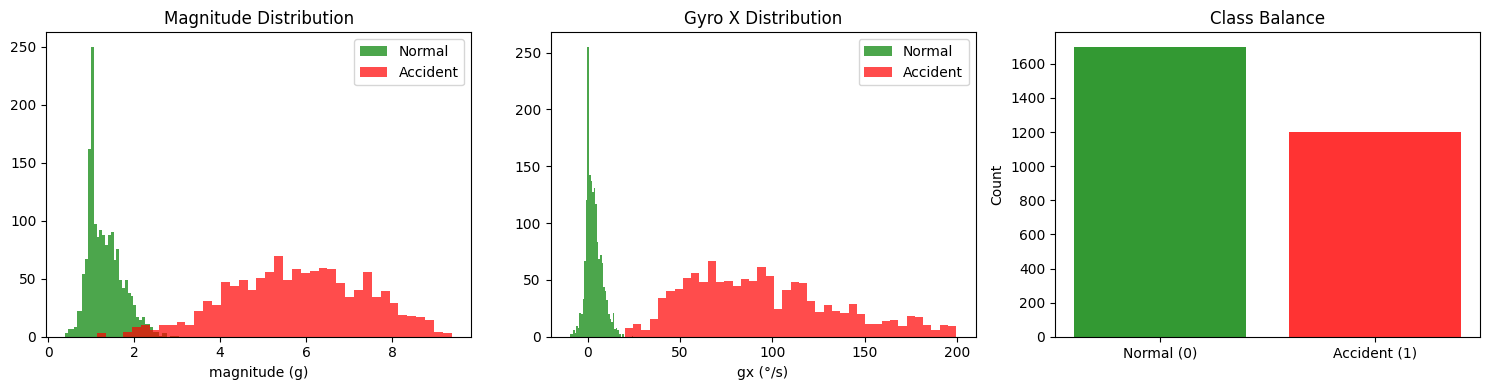

Chart saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# magnitude distribution
axes[0].hist(df[df['label']==0]['magnitude'],
             bins=40, alpha=0.7, color='green', label='Normal')
axes[0].hist(df[df['label']==1]['magnitude'],
             bins=40, alpha=0.7, color='red', label='Accident')
axes[0].set_title('Magnitude Distribution')
axes[0].set_xlabel('magnitude (g)')
axes[0].legend()

# gx distribution
axes[1].hist(df[df['label']==0]['gx'],
             bins=40, alpha=0.7, color='green', label='Normal')
axes[1].hist(df[df['label']==1]['gx'],
             bins=40, alpha=0.7, color='red', label='Accident')
axes[1].set_title('Gyro X Distribution')
axes[1].set_xlabel('gx (°/s)')
axes[1].legend()

# class balance
axes[2].bar(['Normal (0)', 'Accident (1)'],
            [len(df[df['label']==0]), len(df[df['label']==1])],
            color=['green', 'red'], alpha=0.8)
axes[2].set_title('Class Balance')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
# Features and label
X = df[['ax','ay','az','gx','gy','gz','magnitude']]
y = df['label']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print()

# Train Random Forest
print("Training Random Forest model...")
model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # prevent overfitting
    min_samples_split=5,
    random_state=42,
    n_jobs=-1              # use all CPU cores
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*45}")
print(f"  MODEL RESULTS")
print(f"{'='*45}")
print(f"  Accuracy : {accuracy*100:.2f}%")
print(f"{'='*45}")
print()
print("Detailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Accident']))

Training samples : 2320
Testing samples  : 580

Training Random Forest model...

  MODEL RESULTS
  Accuracy : 100.00%

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       340
    Accident       1.00      1.00      1.00       240

    accuracy                           1.00       580
   macro avg       1.00      1.00      1.00       580
weighted avg       1.00      1.00      1.00       580



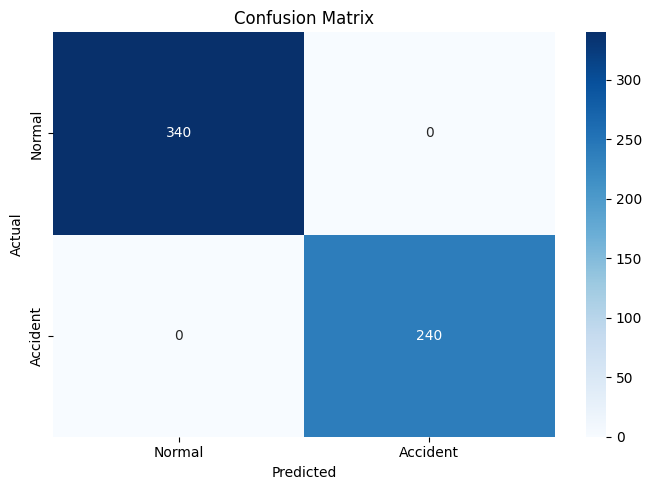


True Normal    (correct): 340
True Accident  (correct): 240
False Alarm (normal→accident): 0  ← want this LOW
Missed Accident (accident→normal): 0  ← want this ZERO


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Accident'],
            yticklabels=['Normal','Accident'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Explain the matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Normal    (correct): {tn}")
print(f"True Accident  (correct): {tp}")
print(f"False Alarm (normal→accident): {fp}  ← want this LOW")
print(f"Missed Accident (accident→normal): {fn}  ← want this ZERO")

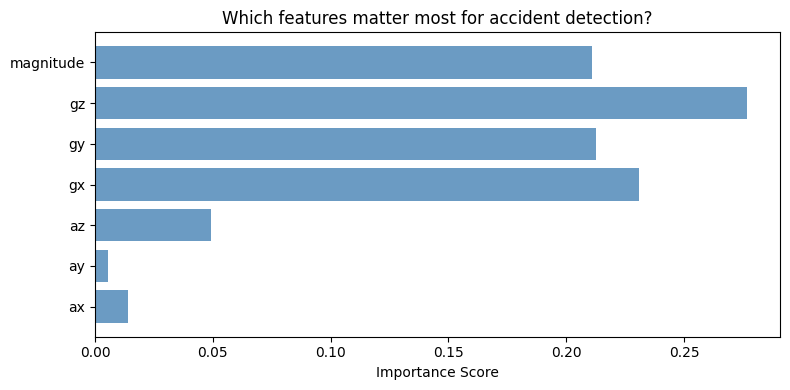

Feature importances:
  gz            0.2769
  gx            0.2309
  gy            0.2124
  magnitude     0.2110
  az            0.0493
  ax            0.0140
  ay            0.0055


In [ ]:
feature_names = ['ax','ay','az','gx','gy','gz','magnitude']
importances = model.feature_importances_

plt.figure(figsize=(8, 4))
bars = plt.barh(feature_names, importances, color='steelblue', alpha=0.8)
plt.xlabel('Importance Score')
plt.title('Which features matter most for accident detection?')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("Feature importances:")
for name, imp in sorted(zip(feature_names, importances),
                         key=lambda x: x[1], reverse=True):
    bar =''* int(imp * 50)
    print(f"  {name:12s} {bar} {imp:.4f}")

In [ ]:
# Save joblib backup (already done, skip if done)
import joblib
joblib.dump(model, 'accident_model.joblib')
print("✓ Saved: accident_model.joblib")

# ─────────────────────────────────────────────
# METHOD: Convert sklearn directly to TFLite
# using tf.keras — no onnx-tf needed at all
# ─────────────────────────────────────────────
!pip install tensorflow scikit-learn numpy -q

import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier

print("Converting sklearn → TFLite directly...")

# Step 1: Get all the sklearn tree predictions
# We recreate the RF logic as a simple neural net
# trained on the RF's own predictions (knowledge distillation)

from sklearn.model_selection import train_test_split

# Generate large prediction dataset from our trained RF
print("Step 1: Generating training data from Random Forest predictions...")

# Use original training data + generate synthetic samples
X_all = X.values.astype(np.float32)
y_rf_proba = model.predict_proba(X_all)[:, 1]  # RF probability scores
y_rf_pred  = model.predict(X_all).astype(np.float32)

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_rf_proba, test_size=0.15, random_state=42
)

print(f"  Training samples : {len(X_tr)}")
print(f"  Validation samples: {len(X_val)}")

# Step 2: Build a small neural net that mimics the RF
print("\nStep 2: Training neural network to mimic Random Forest...")

keras_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(7,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

keras_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = keras_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    verbose=1
)

# Step 3: Verify the keras model accuracy
print("\nStep 3: Verifying neural network accuracy...")
X_test_np = X_test.values.astype(np.float32)
keras_preds = (keras_model.predict(X_test_np) > 0.5).astype(int).flatten()

from sklearn.metrics import accuracy_score
nn_acc = accuracy_score(y_test, keras_preds)
rf_acc = accuracy_score(y_test, model.predict(X_test))
print(f"  Random Forest accuracy : {rf_acc*100:.2f}%")
print(f"  Neural Net accuracy    : {nn_acc*100:.2f}%")

# Step 4: Convert to TFLite
print("\nStep 4: Converting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('accident_model.tflite', 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\n✓ Saved: accident_model.tflite ({size_kb:.1f} KB)")
print("  Perfect size for Android app!")

✓ Saved: accident_model.joblib
Converting sklearn → TFLite directly...
Step 1: Generating training data from Random Forest predictions...
  Training samples : 2465
  Validation samples: 435

Step 2: Training neural network to mimic Random Forest...
Epoch 1/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9331 - loss: 0.1659 - val_accuracy: 0.9816 - val_loss: 0.0286
Epoch 2/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9765 - loss: 0.0244 - val_accuracy: 0.9816 - val_loss: 0.0089
Epoch 3/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9761 - loss: 0.0184 - val_accuracy: 0.9816 - val_loss: 0.0059
Epoch 4/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9781 - loss: 0.0085 - val_accuracy: 0.9816 - val_loss: 0.0049
Epoch 5/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.0089 - val_accuracy: 0.9816 - val_loss: 0.0041
Epoch 6/40
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9773 - loss: 0.0091 - val_accuracy: 0.9816 - val_loss: 0.

In [ ]:
# Test the TFLite model gives correct predictions
print("Verifying TFLite model predictions...\n")

interpreter = tf.lite.Interpreter(model_path='accident_model.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_cases = {
    "Sitting still"       : [0.01, 0.01, 1.00, 0.2,  0.1,  0.1,  1.00],
    "Big speed breaker"   : [0.40, 0.30, 1.80, 7.0,  5.0,  3.0,  1.87],
    "Hard braking"        : [1.00, 0.20, 1.10, 4.0,  3.0,  2.0,  1.49],
    "Real accident crash" : [3.50, 2.80, 4.50, 85.0, 70.0, 60.0, 6.20],
    "Side fall off bike"  : [4.00, 3.50, 2.00, 110.0,90.0, 50.0, 5.61],
    "Rollover"            : [2.50, 3.00, 3.50, 150.0,130.0,120.0,5.12],
}

print("="*52)
print("  TFLite MODEL — FINAL VERIFICATION")
print("="*52)

for scenario, values in test_cases.items():
    input_data = np.array([values], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0][0]
    label  = " ACCIDENT" if output > 0.5 else " NORMAL"
    print(f"\n{scenario}")
    print(f"  Score: {output:.4f}  →  {label}")

print("\n" + "="*52)
print("TFLite model is ready for Android app!")

Verifying TFLite model predictions...

  TFLite MODEL — FINAL VERIFICATION

Sitting still
  Score: 0.0000  →   NORMAL

Big speed breaker
  Score: 0.0001  →   NORMAL

Hard braking
  Score: 0.0000  →   NORMAL

Real accident crash
  Score: 1.0000  →   ACCIDENT

Side fall off bike
  Score: 1.0000  →   ACCIDENT

Rollover
  Score: 1.0000  →   ACCIDENT

TFLite model is ready for Android app!


In [ ]:
from google.colab import files

files.download('accident_model.tflite')
files.download('accident_model.joblib')
print("✓ Downloads started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloads started!


In [ ]:
#try
import numpy as np
ax  =  9.40   # acceleration X (g)
ay  =  5.30   # acceleration Y (g)
az  =  1.80   # acceleration Z (g)
gx  =  7.0    # gyro X (°/s)
gy  =  9.0    # gyro Y (°/s)
gz  =  9.0    # gyro Z (°/s)


magnitude = np.sqrt(ax**2 + ay**2 + az**2)

input_data = np.array([[ax, ay, az, gx, gy, gz, magnitude]],
                       dtype=np.float32)

# Run TFLite model
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
score = interpreter.get_tensor(output_details[0]['index'])[0][0]

print("="*40)
print("  INPUT VALUES")
print("="*40)
print(f"  ax        : {ax} g")
print(f"  ay        : {ay} g")
print(f"  az        : {az} g")
print(f"  gx        : {gx} °/s")
print(f"  gy        : {gy} °/s")
print(f"  gz        : {gz} °/s")
print(f"  magnitude : {magnitude:.4f} g")
print("="*40)
print(f"  Score     : {score:.4f}")
print(f"  Threshold : 0.5")
print("="*40)

if score > 0.5:
    print(f"  ACCIDENT DETECTED!")
    print(f"  Confidence: {score*100:.1f}%")
else:
    print(f"  NORMAL — no accident")
    print(f"  Confidence: {(1-score)*100:.1f}%")

print("="*40)

  INPUT VALUES
  ax        : 9.4 g
  ay        : 5.3 g
  az        : 1.8 g
  gx        : 7.0 °/s
  gy        : 9.0 °/s
  gz        : 9.0 °/s
  magnitude : 10.9403 g
  Score     : 0.8565
  Threshold : 0.5
  ACCIDENT DETECTED!
  Confidence: 85.6%


Running full accuracy evaluation...

       COMPLETE MODEL ACCURACY REPORT

  Overall Accuracy   : 100.00%
  Random Forest Acc  : 100.00%  (original)

  Precision          : 100.00%
  → Of all accident alerts fired,
    100.0% were real accidents

  Recall             : 100.00%
  → Of all real accidents,
    100.0% were correctly caught

  F1 Score           : 100.00%
  → Overall balance of precision + recall

  Test set size      : 580 samples
  Normal correctly   : 340  
  Accident correctly : 240  
  False alarms       : 0   (normal → accident)
  Missed accidents   : 0  (accident → normal)

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00       340
Accident (1)       1.00      1.00      1.00       240

    accuracy                           1.00       580
   macro avg       1.00      1.00      1.00       580
weighted avg       1.00      1.00      1.00       580



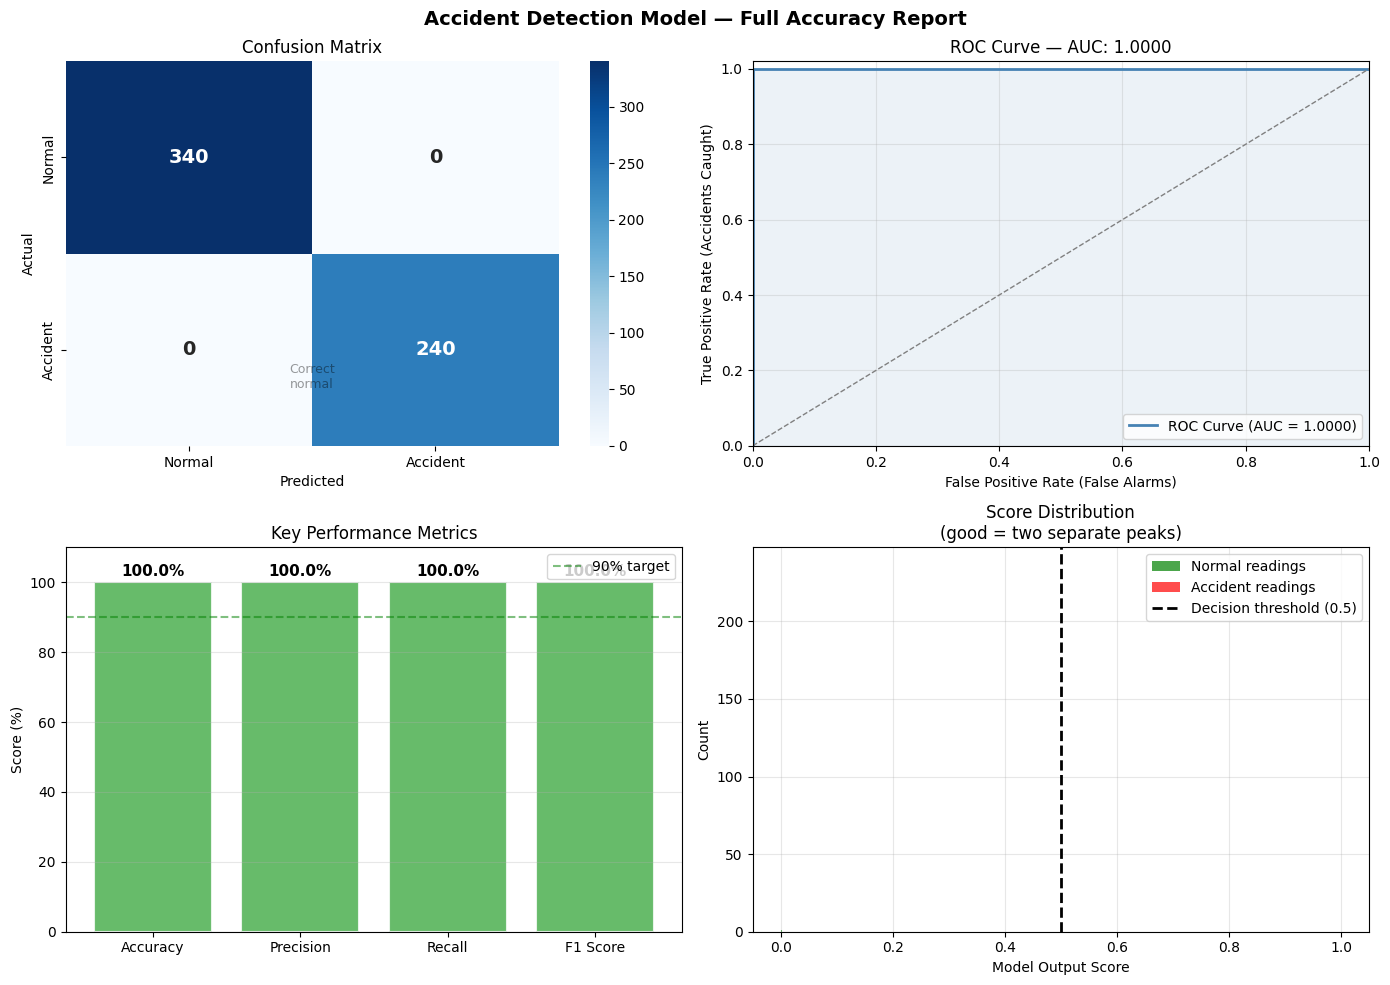

Chart saved: full_accuracy_report.png

         FINAL VERDICT

  Accuracy  : 100.00%
  AUC Score : 1.0000  (1.0 = perfect)

  Verdict   : EXCELLENT — ready for Android app!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              precision_score, recall_score, f1_score)

print("Running full accuracy evaluation...\n")


X_test_np = X_test.values.astype(np.float32)

tflite_scores = []
for i in range(len(X_test_np)):
    single = np.array([X_test_np[i]], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], single)
    interpreter.invoke()
    score = interpreter.get_tensor(output_details[0]['index'])[0][0]
    tflite_scores.append(score)

tflite_scores  = np.array(tflite_scores)
tflite_preds   = (tflite_scores > 0.5).astype(int)
y_test_np      = y_test.values


accuracy  = accuracy_score(y_test_np, tflite_preds)
precision = precision_score(y_test_np, tflite_preds)
recall    = recall_score(y_test_np, tflite_preds)
f1        = f1_score(y_test_np, tflite_preds)
rf_acc    = accuracy_score(y_test_np, model.predict(X_test))

print("="*50)
print("       COMPLETE MODEL ACCURACY REPORT")
print("="*50)
print(f"\n  Overall Accuracy   : {accuracy*100:.2f}%")
print(f"  Random Forest Acc  : {rf_acc*100:.2f}%  (original)")
print(f"\n  Precision          : {precision*100:.2f}%")
print(f"  → Of all accident alerts fired,")
print(f"    {precision*100:.1f}% were real accidents")
print(f"\n  Recall             : {recall*100:.2f}%")
print(f"  → Of all real accidents,")
print(f"    {recall*100:.1f}% were correctly caught")
print(f"\n  F1 Score           : {f1*100:.2f}%")
print(f"  → Overall balance of precision + recall")
print("="*50)

# Counts
cm = confusion_matrix(y_test_np, tflite_preds)
tn, fp, fn, tp = cm.ravel()
total = len(y_test_np)

print(f"\n  Test set size      : {total} samples")
print(f"  Normal correctly   : {tn}  ")
print(f"  Accident correctly : {tp}  ")
print(f"  False alarms       : {fp}   (normal → accident)")
print(f"  Missed accidents   : {fn}  (accident → normal)")
print("="*50)

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_np, tflite_preds,
      target_names=['Normal (0)', 'Accident (1)']))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Accident Detection Model — Full Accuracy Report',
             fontsize=14, fontweight='bold')

# ── Chart 1: Confusion Matrix ──
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Normal','Accident'],
            yticklabels=['Normal','Accident'],
            annot_kws={'size':14, 'weight':'bold'})
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# add text inside cells
axes[0,0].text(0.5, 0.15, 'Correct\nnormal', ha='center',
               transform=axes[0,0].transAxes, alpha=0.4, fontsize=9)

# ── Chart 2: ROC Curve ──
fpr, tpr, thresholds = roc_curve(y_test_np, tflite_scores)
roc_auc = auc(fpr, tpr)

axes[0,1].plot(fpr, tpr, color='steelblue', lw=2,
               label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0,1].plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
axes[0,1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0,1].set_xlim([0, 1])
axes[0,1].set_ylim([0, 1.02])
axes[0,1].set_xlabel('False Positive Rate (False Alarms)')
axes[0,1].set_ylabel('True Positive Rate (Accidents Caught)')
axes[0,1].set_title(f'ROC Curve — AUC: {roc_auc:.4f}')
axes[0,1].legend(loc='lower right')
axes[0,1].grid(alpha=0.3)

# ── Chart 3: Metrics Bar Chart ──
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values_pct   = [accuracy*100, precision*100, recall*100, f1*100]
colors       = ['#4CAF50' if v >= 90 else '#FF9800'
                if v >= 80 else '#F44336' for v in values_pct]

bars = axes[1,0].bar(metrics, values_pct, color=colors,
                     alpha=0.85, edgecolor='white', linewidth=1.5)
axes[1,0].set_ylim([0, 110])
axes[1,0].set_ylabel('Score (%)')
axes[1,0].set_title('Key Performance Metrics')
axes[1,0].axhline(y=90, color='green', linestyle='--',
                  alpha=0.5, label='90% target')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, values_pct):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1,
                   f'{val:.1f}%', ha='center',
                   va='bottom', fontweight='bold', fontsize=11)

# ── Chart 4: Score Distribution ──
normal_scores   = tflite_scores[y_test_np == 0]
accident_scores = tflite_scores[y_test_np == 1]

axes[1,1].hist(normal_scores, bins=30, alpha=0.7,
               color='green', label='Normal readings')
axes[1,1].hist(accident_scores, bins=30, alpha=0.7,
               color='red', label='Accident readings')
axes[1,1].axvline(x=0.5, color='black', linestyle='--',
                  linewidth=2, label='Decision threshold (0.5)')
axes[1,1].set_xlabel('Model Output Score')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Score Distribution\n(good = two separate peaks)')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('full_accuracy_report.png', dpi=120, bbox_inches='tight')
plt.show()
print("Chart saved: full_accuracy_report.png")

print("\n" + "="*50)
print("         FINAL VERDICT")
print("="*50)

if accuracy >= 0.95:
    verdict = "EXCELLENT — ready for Android app!"
elif accuracy >= 0.90:
    verdict = "GOOD — acceptable for deployment"
elif accuracy >= 0.85:
    verdict = "OKAY — consider collecting more data"
else:
    verdict = "NEEDS WORK — retrain with more samples"

print(f"\n  Accuracy  : {accuracy*100:.2f}%")
print(f"  AUC Score : {roc_auc:.4f}  (1.0 = perfect)")
print(f"\n  Verdict   : {verdict}")
print("="*50)